In [ ]:
import json
from pathlib import Path

from db_tools.sqlite import connect_sqlite

with connect_sqlite(Path("datasheets/datasheet_tracker"), readonly=True) as conn:
    rows = conn.execute("SELECT * FROM datasheet_tracker").fetchall()
    entries = [dict(row) for row in rows]

In [ ]:
symbol_json_path = "test_cases/test_audio_amplifier/symbols/94e6638093ff4ff4bc5663dba417b306.json"

with open(symbol_json_path, "r") as f:
    symbol_json = json.load(f)

name = symbol_json["name"]

for row in entries:
    if row["symbol_name"] == name:
        lib = row["library"]
        break

print(name)
print(lib)

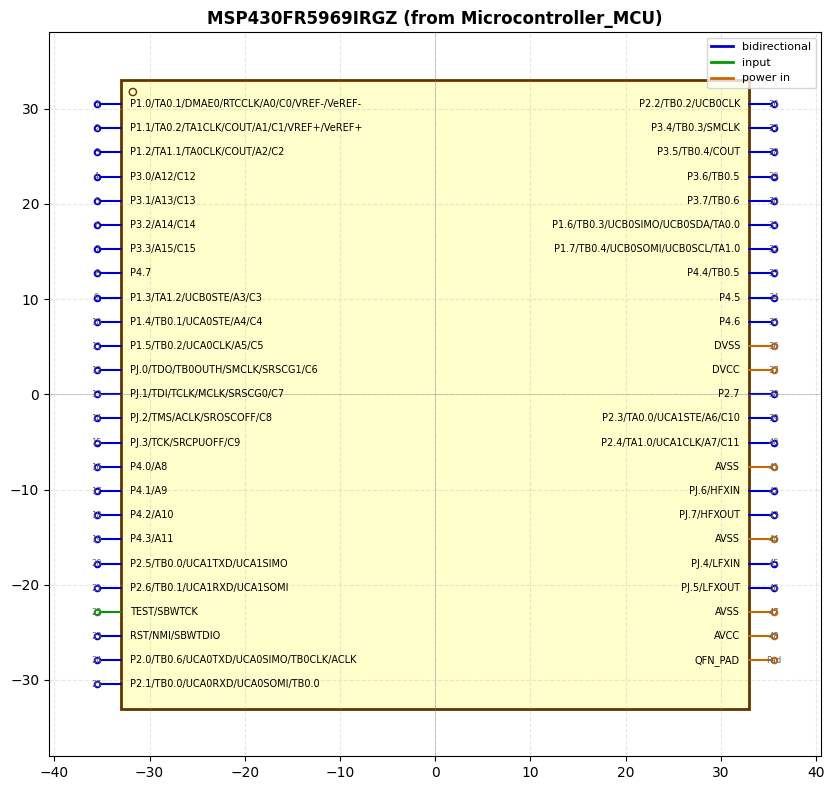

In [1]:
from python.commands.database_tools.symbol_visualizer import visualize_by_mpn

s = visualize_by_mpn("MSP430FR5969IRGZ", "Microcontroller_MCU", show=False)

In [ ]:
from python.commands.database_tools.symbol_builders import build_symbol_from_json
from python.commands.database_tools.symbol_visualizer import visualize_symbol

sexp = build_symbol_from_json(symbol_json)
fig = visualize_symbol(sexp, show=False)

In [ ]:
from python.commands.database_tools.library_schematic import LibraryManager
result = LibraryManager.add_symbol_entry({
    "mpn": name,
    "library": lib,
    "sexp": sexp,
    "overwrite": True,
})
print(result)

In [ ]:
s1 = visualize_by_mpn(name, lib, show=False)